In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
import imageio.v2 as imageio
from pathlib import Path

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


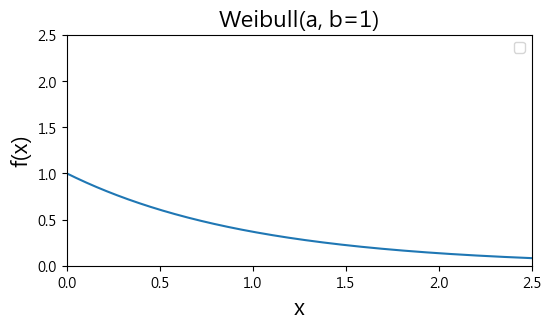

In [31]:
def Weibull(x, a, b):
    if a<=0 and b<=0:
        raise ValueError('a and b must be positive')
    x = np.asarray(x, dtype='float')
    y = np.zeros_like(x)
    mask = x >= 0
    xm = x[mask]
    y = (b/a)*(xm/a)**(b-1)*np.exp(-(xm/a)**b)
    return y
a = 1
b = 1
x = np.linspace(0, 2.5, 500)
y = Weibull(x, a, b)
plt.figure(figsize=(6, 3))
plt.plot(x, y)
plt.title('Weibull(a, b=1)', fontsize=16)
plt.xlabel('x', fontsize=16)
plt.ylabel('f(x)', fontsize=16)
plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.legend()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_34872\603649450.py:8: RuntimeWarning: divide by zero encountered in power
  y = (b/a)*(xm/a)**(b-1)*np.exp(-(xm/a)**b)


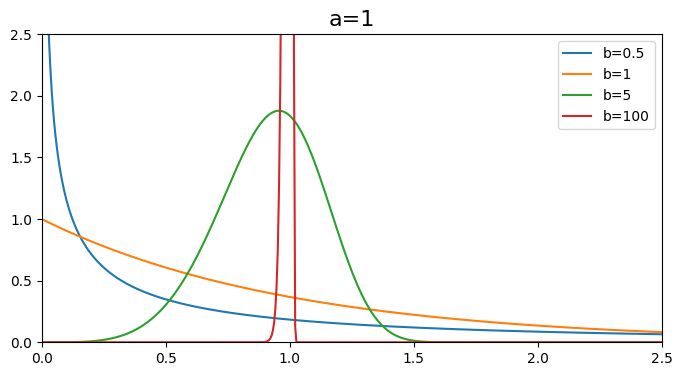

In [10]:
def Weibull(x, a, b):
    if a<=0 and b<=0:
        raise ValueError('a and b must be positive')
    x = np.asarray(x, dtype='float')
    y = np.zeros_like(x)
    mask = x >= 0
    xm = x[mask]
    y = (b/a)*(xm/a)**(b-1)*np.exp(-(xm/a)**b)
    return y
a = 1
b_list = [0.5, 1, 5, 100]
x = np.linspace(0, 2.5, 500)

plt.figure(figsize=(8, 4))
for b in b_list:
    y = Weibull(x, a, b)
    plt.plot(x, y, label=f'b={b}')
plt.title('a=1', fontsize=16)
plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.legend()
plt.show()

In [30]:

def Weibull(x, a, b):
    if (a <= 0) or (b <= 0):
        raise ValueError("a and b must be positive")
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    mask = x >= 0
    xm = x[mask]
    y[mask] = (b/a) * (xm/a)**(b-1) * np.exp(-(xm/a)**b)
    return y

# ====== 設定 ======
a = 1.0
x = np.linspace(0, 2.5, 600)

# 建議用 log-space 讓 b 從小到大變化更平滑
b_vals = np.geomspace(0.5, 100, 60)  # 60 frames: b=0.5 -> 100
# 若想只跑你原本四個點，就改成: b_vals = [0.5, 1, 5, 100]

out_dir = Path("weibull_anim")
frames_dir = out_dir / "frames"
frames_dir.mkdir(parents=True, exist_ok=True)

gif_path = out_dir / "weibull_a1_b_sweep.gif"

# y 軸上限建議固定，避免動畫縮放造成視覺誤判
ymax = 2.5

# ====== 產生 frames ======
frame_paths = []
for i, b in enumerate(b_vals, start=1):
    y = Weibull(x, a, float(b))

    fig = plt.figure(figsize=(8, 4))
    ax = fig.add_subplot(111)
    ax.plot(x, y, linewidth=2)
    ax.set_title(rf"Weibull PDF ($a=1$, $b={b:.3g}$)", fontsize=16)
    ax.set_xlim(0, 2.5)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("x", fontsize=16)
    ax.set_ylabel("f(x)", fontsize=16)
    ax.grid(True, alpha=0.3)

    fp = frames_dir / f"frame_{i:03d}.png"
    fig.savefig(fp, dpi=160, bbox_inches="tight")
    plt.close(fig)
    frame_paths.append(fp)

# ====== 組 GIF ======
imgs = [imageio.imread(p) for p in frame_paths]
imageio.mimsave(gif_path, imgs, duration=0.08, loop=0)  # 0.08s/frame

print("GIF saved to:", gif_path)
print("Frames saved to:", frames_dir)

C:\Users\USER\AppData\Local\Temp\ipykernel_34872\2569458625.py:8: RuntimeWarning: divide by zero encountered in power
  y[mask] = (b/a) * (xm/a)**(b-1) * np.exp(-(xm/a)**b)


GIF saved to: weibull_anim\weibull_a1_b_sweep.gif
Frames saved to: weibull_anim\frames


=== True parameters ===
lambda_true = 0.500000
a_true (scale) = 2.000000
b_true (shape) = 1.000000
True mean = 2.000000

=== Fitted (Weibull MLE) ===
b_hat (shape) = 0.985006
a_hat (scale) = 2.030194
Estimated mean (Weibull) = 2.043455
lambda_hat (if treat as exponential) = 0.492564

=== P(X < 5) comparison ===
Theoretical (Exp)   = 0.917915
Empirical (sample)  = 0.935000
Fitted Weibull CDF  = 0.911942


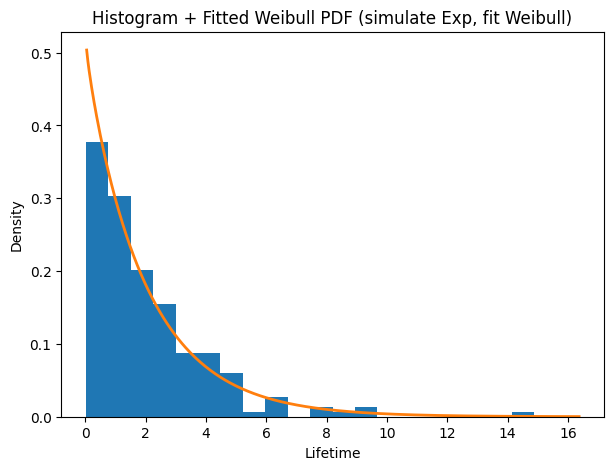

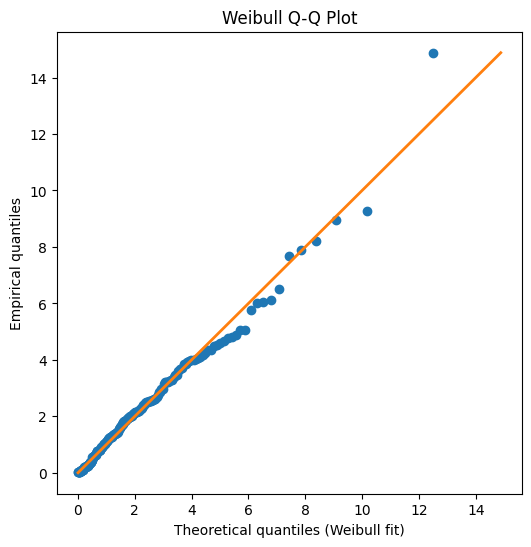

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma

# ---------- 0) 真實設定：指數分配 λ=0.5  <=>  Weibull(b=1, a=1/λ=2) ----------
lam_true = 0.5
a_true = 1.0 / lam_true   # 2.0
b_true = 1.0

# ---------- 1) 模擬資料（壽命） ----------
rng = np.random.default_rng(611211106)
n = 200
t = rng.exponential(scale=a_true, size=n)   # 指數分配：scale = 1/λ = a_true

# ---------- 2) 反推 Weibull 參數（MLE，loc=0） ----------
b_hat, loc_hat, a_hat = stats.weibull_min.fit(t, floc=0)

# ---------- 3) 反推期望值 ----------
mu_hat = a_hat * gamma(1.0 + 1.0 / b_hat)

# 也可把 Weibull 估計結果轉回「等效指數率」(僅在 b≈1 時才有意義)
lam_hat_if_exp = 1.0 / a_hat

print("=== True parameters ===")
print(f"lambda_true = {lam_true:.6f}")
print(f"a_true (scale) = {a_true:.6f}")
print(f"b_true (shape) = {b_true:.6f}")
print(f"True mean = {a_true * gamma(1 + 1/b_true):.6f}")  # b=1 => mean=a

print("\n=== Fitted (Weibull MLE) ===")
print(f"b_hat (shape) = {b_hat:.6f}")
print(f"a_hat (scale) = {a_hat:.6f}")
print(f"Estimated mean (Weibull) = {mu_hat:.6f}")
print(f"lambda_hat (if treat as exponential) = {lam_hat_if_exp:.6f}")

# ---------- 4) 題型對照：P(X < 5) ----------
x0 = 5.0
p_true = 1.0 - np.exp(-lam_true * x0)  # 指數分配 CDF
p_emp = np.mean(t < x0)               # 模擬資料的經驗比例
p_fit = stats.weibull_min.cdf(x0, c=b_hat, loc=0, scale=a_hat)  # 擬合 Weibull 的 CDF

print("\n=== P(X < 5) comparison ===")
print(f"Theoretical (Exp)   = {p_true:.6f}")
print(f"Empirical (sample)  = {p_emp:.6f}")
print(f"Fitted Weibull CDF  = {p_fit:.6f}")

# ---------- 5) 視覺：直方圖 + 擬合 PDF（不會溢位的版本） ----------
x = np.linspace(0, t.max() * 1.1, 400)
pdf_hat = stats.weibull_min.pdf(x, c=b_hat, loc=0, scale=a_hat)

plt.figure(figsize=(7, 5))
plt.hist(t, bins=20, density=True)
plt.plot(x, pdf_hat, linewidth=2)
plt.xlabel("Lifetime")
plt.ylabel("Density")
plt.title("Histogram + Fitted Weibull PDF (simulate Exp, fit Weibull)")
plt.show()

# ---------- 6) 視覺：Q-Q plot ----------
n = len(t)
p = (np.arange(1, n + 1) - 0.5) / n
theo_q = stats.weibull_min.ppf(p, c=b_hat, loc=0, scale=a_hat)
emp_q = np.sort(t)

plt.figure(figsize=(6, 6))
plt.plot(theo_q, emp_q, marker='o', linestyle='none')
m = min(theo_q.min(), emp_q.min())
M = max(theo_q.max(), emp_q.max())
plt.plot([m, M], [m, M], linewidth=2)
plt.xlabel("Theoretical quantiles (Weibull fit)")
plt.ylabel("Empirical quantiles")
plt.title("Weibull Q-Q Plot")
plt.show()